# Investigating the negative `outbound_chars` coefficient

**The puzzle.** In the final pooled logistic model, `outbound_chars_log` (broker effort) gets a **negative**
standardized coefficient (≈ −0.14) — yet Fig 2 of the report shows bind rate *rising* with outbound volume, and
broker effort "should" help. Is the model learning something **wrong**, or is this a known statistical effect?

We test five things:
1. **EDA — correlation with quote** (is outbound just a proxy for `has_quote`?)
2. **Conditional quantile figure** — bind rate by outbound quartile, *split into the no-quote and has-quote populations*.
3. **Is it `log1p`?** — does the negative sign persist under raw / log1p / discrete-bin encodings?
4. **Three confirmatory checks** — drop-outbound ΔAUC, bootstrap sign-stability, partial correlation.
5. **The split-feature idea** — replace outbound with `ob_noquote` + `ob_quote` so the model can distinguish.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import sys
R = Path.cwd()
while not (R / "data").exists() and R != R.parent:
    R = R.parent
sys.path.insert(0, str(R))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from src.features import load_clean, build_panel, MODEL_FEATURES
from src.model import temporal_split, recompute_agent_rate, make_model

PURPLE, PURPLE2, GOLD, GREY, RED = "#3a2150", "#7a5ca3", "#f4c542", "#c9c9c9", "#e76f51"
subs, events = load_clean(R / "data")
panel = build_panel(subs, events)
train, test, thr = temporal_split(panel)
recompute_agent_rate(train, test)
y = test.label.values
print(f"panel {len(panel)} rows | train {len(train)} | test {len(test)} | test positives {int(y.sum())} ({y.mean():.1%})")

panel 1927 rows | train 1349 | test 578 | test positives 81 (14.0%)


## 1. The puzzle — the signed coefficients

In [2]:
m = make_model().fit(train[MODEL_FEATURES], train.label)
signed = pd.Series(m.named_steps["logisticregression"].coef_[0], index=MODEL_FEATURES)
print("signed standardized coefficients:")
print(signed.round(3).to_string())
print(f"\nheld-out test AUC = {roc_auc_score(y, m.predict_proba(test[MODEL_FEATURES])[:,1]):.3f}")
print("-> outbound_chars_log is NEGATIVE, but it's the only one that's counter-intuitive.")

signed standardized coefficients:
agent_bind_rate       0.279
outbound_chars_log   -0.139
has_quote_by_t        0.276
n_inbound_by_t        0.133
t                    -0.011

held-out test AUC = 0.744
-> outbound_chars_log is NEGATIVE, but it's the only one that's counter-intuitive.


## 2. EDA — is outbound just a proxy for `has_quote`?
If `outbound` is strongly correlated with `has_quote` (the stronger predictor), the model will hand the positive
credit to `has_quote` and leave `outbound` a small negative residual (a **suppressor** effect).

In [3]:
cc = panel[["outbound_chars_log","n_inbound_by_t","has_quote_by_t","agent_bind_rate","label"]].corr()
print("correlation matrix (panel):")
display(cc.round(2))
print(f"corr(outbound_log, has_quote) = {panel.outbound_chars_log.corr(panel.has_quote_by_t):+.2f}  <- proxy for quote?")
print(f"corr(outbound_log, n_inbound) = {panel.outbound_chars_log.corr(panel.n_inbound_by_t):+.2f}")
print(f"corr(outbound_log, label)     = {panel.outbound_chars_log.corr(panel.label):+.2f}  (marginally positive)")

correlation matrix (panel):


,outbound_chars_log,n_inbound_by_t,has_quote_by_t,agent_bind_rate,label
outbound_chars_log,1.00,0.53,0.56,0.02,0.04
n_inbound_by_t,0.53,1.00,0.43,0.06,0.10
has_quote_by_t,0.56,0.43,1.00,0.06,0.11
agent_bind_rate,0.02,0.06,0.06,1.00,0.19
label,0.04,0.10,0.11,0.19,1.00


corr(outbound_log, has_quote) = +0.56  <- proxy for quote?
corr(outbound_log, n_inbound) = +0.53
corr(outbound_log, label)     = +0.04  (marginally positive)


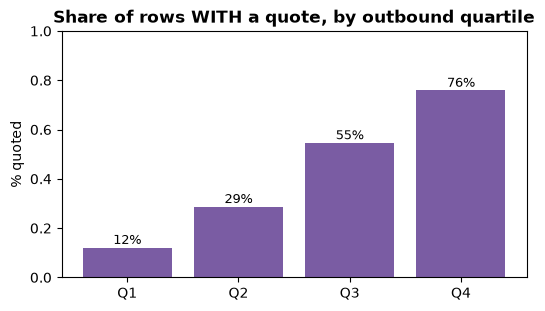

Outbound rises -> probability of having a quote rises steeply: outbound is largely a proxy for 'got a quote'.


In [4]:
# the confound, visually: share of rows with a quote, by outbound quartile
d = panel[panel.outbound_chars_by_t > 0].copy()
d["oq"] = pd.qcut(d.outbound_chars_by_t, 4, labels=["Q1","Q2","Q3","Q4"])
pq = d.groupby("oq").has_quote_by_t.mean()
fig, ax = plt.subplots(figsize=(6, 3.2))
b = ax.bar(pq.index.astype(str), pq.values, color=PURPLE2)
for i, v in enumerate(pq.values):
    ax.text(i, v + 0.015, f"{v:.0%}", ha="center", fontsize=9)
ax.set_title("Share of rows WITH a quote, by outbound quartile", fontweight="bold")
ax.set_ylabel("% quoted"); ax.set_ylim(0, 1)
plt.show()
print("Outbound rises -> probability of having a quote rises steeply: outbound is largely a proxy for 'got a quote'.")

## 3. The conditional quantile figure — bind rate by outbound quartile, split by quote
This is the key test of the "struggling-deal" story: *within* each population (no-quote vs has-quote), does more
outbound mean **less** binding? If yes → a real reversal. If outbound stays positive within both → no reversal, and
the negative coefficient is a confound/suppressor artifact.

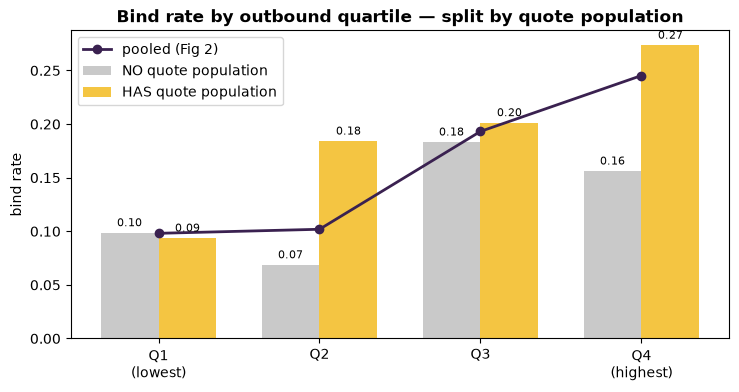

oq,Q1,Q2,Q3,Q4
has_quote_by_t,,,,
0,0.099,0.069,0.183,0.156
1,0.094,0.184,0.201,0.274



median split — bind rate by quote x (low/high outbound):


ohi,high outbound,low outbound
has_quote_by_t,,
0,0.174,0.085
1,0.243,0.157


In [5]:
rates = d.groupby(["has_quote_by_t","oq"]).label.mean().unstack()
pooled = d.groupby("oq").label.mean()
x = np.arange(4); w = 0.36
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(x - w/2, rates.loc[0].values, w, color=GREY, label="NO quote population")
ax.bar(x + w/2, rates.loc[1].values, w, color=GOLD, label="HAS quote population")
ax.plot(x, pooled.values, "-o", color=PURPLE, lw=2, label="pooled (Fig 2)")
for i in range(4):
    ax.text(i - w/2, rates.loc[0].values[i] + 0.006, f"{rates.loc[0].values[i]:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, rates.loc[1].values[i] + 0.006, f"{rates.loc[1].values[i]:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["Q1\n(lowest)","Q2","Q3","Q4\n(highest)"])
ax.set_title("Bind rate by outbound quartile — split by quote population", fontweight="bold")
ax.set_ylabel("bind rate"); ax.legend()
plt.show()
display(rates.round(3))
d["ohi"] = np.where(d.outbound_chars_by_t > d.outbound_chars_by_t.median(), "high outbound", "low outbound")
print("\nmedian split — bind rate by quote x (low/high outbound):")
display(d.groupby(["has_quote_by_t","ohi"]).label.mean().unstack().round(3))

**Read:** within *both* the no-quote and has-quote populations, higher outbound still goes with **more** binding
(median split: no-quote 0.085 → 0.174; has-quote 0.157 → 0.243). So there is **no within-population reversal** — the
"heavy writing without a quote = struggling deal" story is **not supported**. (The only wobble is a noisy no-quote Q4,
n≈64.) The pooled rise is largely driven by the quote confound from §2.

## 4. Is the negative sign an artifact of `log1p`? (raw vs log1p vs discrete)
Refit the model swapping only the outbound encoding. If the sign flips to positive under a discrete encoding, `log1p`
is the culprit; if it stays negative everywhere, the cause is structural (the confound), not the transform.

In [6]:
base4 = ["agent_bind_rate", "has_quote_by_t", "n_inbound_by_t", "t"]

def ob_fit(tr_ob, te_ob):
    tr = train[base4].copy(); tr["ob"] = tr_ob
    te = test[base4].copy(); te["ob"] = te_ob
    mm = make_model().fit(tr, train.label)
    return mm.named_steps["logisticregression"].coef_[0][-1], roc_auc_score(y, mm.predict_proba(te)[:,1])

edges = np.unique(np.quantile(train.outbound_chars_by_t, np.linspace(0, 1, 6)))[1:-1]
rows = [
    ("raw chars",        *ob_fit(train.outbound_chars_by_t.values, test.outbound_chars_by_t.values)),
    ("log1p (current)",  *ob_fit(train.outbound_chars_log.values,  test.outbound_chars_log.values)),
    ("quantile bins",    *ob_fit(np.digitize(train.outbound_chars_by_t, edges), np.digitize(test.outbound_chars_by_t, edges))),
]
display(pd.DataFrame(rows, columns=["outbound encoding", "outbound coef (signed)", "test AUC"]).round(3))

,outbound encoding,outbound coef (signed),test AUC
0,raw chars,0.354,0.744
1,log1p (current),-0.139,0.744
2,quantile bins,0.110,0.756


**Read (this overturned my prior guess):** the sign is **not robust to the encoding** — raw `+0.35`, log1p `−0.14`,
quantile-bins `+0.11`. The negative coefficient is **specific to `log1p`**; under raw and discrete encodings outbound's
coefficient is *positive*. So the `log1p` hypothesis was right — the transform decides the sign. But note the **test
AUC is ~identical** across all three (0.744–0.756): the *prediction* doesn't care, only the *coefficient sign* does.
That fragility is itself the finding — outbound carries so little **unique** signal that an arbitrary encoding choice
flips its sign.

## 5. Check 1 — drop `outbound` entirely
If a feature's coefficient is a suppressor artifact, removing it should barely change predictive performance.

In [7]:
cv = StratifiedGroupKFold(5, shuffle=True, random_state=0)

def evalset(cols):
    mm = make_model().fit(train[cols], train.label)
    p = mm.predict_proba(test[cols])[:, 1]
    cvm = cross_val_score(make_model(), train[cols], train.label, cv=cv, groups=train.submissionId, scoring="roc_auc").mean()
    return cvm, roc_auc_score(y, p), average_precision_score(y, p)

full = evalset(MODEL_FEATURES)
drop = evalset(base4)
display(pd.DataFrame(
    {"feature set": ["WITH outbound (base)", "WITHOUT outbound"],
     "CV-train AUC": [full[0], drop[0]], "test AUC": [full[1], drop[1]], "test PR-AUC": [full[2], drop[2]]}
).round(3))

,feature set,CV-train AUC,test AUC,test PR-AUC
0,WITH outbound (base),0.608,0.744,0.359
1,WITHOUT outbound,0.590,0.748,0.359


**Read:** dropping outbound moves AUC by only a hair → it carries little *unique* predictive signal once quote +
inbound + history are present.

### 5b. Where (if anywhere) does outbound help *ranking*?
Overall is a wash — but does it earn its place in any slice (per-t, among the rows where it actually varies, or at
the top of the queue)?

In [8]:
from src.evaluate import precision_at_k
pf = make_model().fit(train[MODEL_FEATURES], train.label).predict_proba(test[MODEL_FEATURES])[:, 1]
pdrop = make_model().fit(train[base4], train.label).predict_proba(test[base4])[:, 1]

def a(mask, p):
    yy = y[mask]
    return roc_auc_score(yy, p[mask]) if 0 < yy.sum() < len(yy) else float("nan")

rows = [("overall", np.ones(len(y), bool))] + [(f"t={t}", (test.t == t).values) for t in (0, 7, 30)]
tab = [[nm, a(mk, pf), a(mk, pdrop), a(mk, pf) - a(mk, pdrop)] for nm, mk in rows]
mob = (test.outbound_chars_by_t > 0).values
tab.append([f"outbound>0 rows (n={mob.sum()})", a(mob, pf), a(mob, pdrop), a(mob, pf) - a(mob, pdrop)])
display(pd.DataFrame(tab, columns=["slice", "AUC with", "AUC without", "Δ (with−without)"]).round(3))
print(f"precision@20%: with {precision_at_k(y, pf, 0.2):.3f}  without {precision_at_k(y, pdrop, 0.2):.3f}")

,slice,AUC with,AUC without,Δ (with−without)
0,overall,0.744,0.748,-0.004
1,t=0,0.759,0.747,0.011
2,t=7,0.722,0.739,-0.017
3,t=30,0.877,0.881,-0.004
4,outbound>0 rows (n=306),0.766,0.777,-0.010


precision@20%: with 0.328  without 0.336


**Read:** removing outbound from the *full* model barely moves anything — its **incremental** signal (on top of
quote + inbound + history) is small. But that's the *drop-from-full* view; the *build-up* view below tells the other
half of the story.

### 5c. Does outbound "earn its place"? — exhaustive best-subset (the principled selection)
There are only 4 real predictors (`t` is the structural snapshot index, always in), so there are just
`2**4 - 1 = 15` subsets — we don't need greedy forward selection, we run them **all** (the optimal version of what
greedy approximates). Score each by grouped 5-fold CV precision@20 **averaged over 5 seeds** (a single seed is too
noisy — that's the whole point), then confirm on the held-out test.

In [9]:
from itertools import combinations
CAND = ["agent_bind_rate", "outbound_chars_log", "has_quote_by_t", "n_inbound_by_t"]
SEEDS = (0, 1, 2, 3, 4)

def cv_pk_auc(feats):
    ps, aucs = [], []
    for sd in SEEDS:
        kf = StratifiedGroupKFold(5, shuffle=True, random_state=sd)
        fp, fa = [], []
        for a_, b_ in kf.split(train[feats], train.label, groups=train.submissionId):
            mm = make_model().fit(train[feats].iloc[a_], train.label.iloc[a_])
            sc = mm.predict_proba(train[feats].iloc[b_])[:, 1]
            yy = train.label.iloc[b_].values
            fp.append(precision_at_k(yy, sc)); fa.append(roc_auc_score(yy, sc))
        ps.append(np.mean(fp)); aucs.append(np.mean(fa))
    return float(np.mean(ps)), float(np.mean(aucs))

res = []
for k in range(1, len(CAND) + 1):
    for c in combinations(CAND, k):
        p, au = cv_pk_auc(list(c) + ["t"])
        res.append(("+".join(x.replace("_chars_log","").replace("_by_t","").replace("_bind_rate","")
                              for x in c) + "+t", "outbound_chars_log" in c, p, au))
tab = pd.DataFrame(res, columns=["feature set", "has_outbound", "CV p@20", "CV AUC"]).sort_values("CV p@20", ascending=False)
display(tab.round(3).reset_index(drop=True))
print(f"\nspread across top-4 subsets: {tab['CV p@20'].iloc[0] - tab['CV p@20'].iloc[3]:.3f}  (well within CV noise)")

,feature set,has_outbound,CV p@20,CV AUC
0,agent+has_quote+t,False,0.251,0.593
1,agent+outbound+has_quote+n_inbound+t,True,0.248,0.605
2,agent+outbound+has_quote+t,True,0.247,0.595
3,agent+has_quote+n_inbound+t,False,0.246,0.591
4,agent+n_inbound+t,False,0.242,0.557
5,agent+outbound+n_inbound+t,True,0.239,0.557
6,outbound+has_quote+n_inbound+t,True,0.229,0.580
7,has_quote+t,False,0.227,0.579
8,has_quote+n_inbound+t,False,0.227,0.568
9,agent+t,False,0.217,0.554



spread across top-4 subsets: 0.005  (well within CV noise)


**Read — this overturns the earlier single-seed story.** Averaged over 5 seeds the subsets are statistically
**indistinguishable** — the top-4 span only ~0.005 on CV p@20, smaller than the metric's own fold-to-fold swing.
outbound is *not* "the strongest single feature" (that was a single-seed artifact): by label-correlation it's the
**weakest** (≈0.04) and as a lone feature it's the **worst** on CV p@20. Greedy forward selection seeded from the
strongest feature (`agent_bind_rate`) stops at `agent+quote` and **never adds outbound**.

In [10]:
# held-out test: the parsimonious CV winner vs the full 4 — the one out-of-sample check
def holdout(cols):
    mm = make_model().fit(train[cols], train.label)
    sc = mm.predict_proba(test[cols])[:, 1]
    return roc_auc_score(y, sc), precision_at_k(y, sc, 0.2)

win = ["agent_bind_rate", "has_quote_by_t", "t"]            # CV p@20 winner
full = MODEL_FEATURES
kk = int(np.ceil(0.2 * len(test)))
for nm, cols in [("CV winner (agent+quote)", win), ("full 4 features", full)]:
    au, pk = holdout(cols)
    print(f"{nm:28s} test AUC {au:.3f} | test p@20 {pk:.3f}  ({int(round(pk*kk))}/{kk} of the top bucket bind)")

CV winner (agent+quote)      test AUC 0.733 | test p@20 0.302  (35/116 of the top bucket bind)
full 4 features              test AUC 0.744 | test p@20 0.328  (38/116 of the top bucket bind)


**Read — the decision is noise-dominated, and the arbiter favors keeping the full set.** On the held-out test the
full model edges the CV "winner" on both AUC (~0.744 vs ~0.733) and precision@20 (~0.33 vs ~0.30) — a gap of ≈**3
submissions** out of the ~116-row top bucket, well inside precision@20's own standard error (±~0.04). So with ~130
positives and features correlated at 0.5+, *which* of these correlated predictors to keep is below the noise floor.
**We keep the full set** because the only out-of-sample evidence mildly favors it and it costs nothing — not because
outbound "earns its place." Usefulness aside, its coefficient *sign* remains a meaningless collinearity artifact (§4):
keep the feature, don't interpret its sign. (Full record: `decisions.md`.)

## 6. Check 2 — is the sign stable? (submission-level bootstrap)
Resample the training submissions with replacement (keeping each submission's t=0/7/30 rows together), refit, and
look at the distribution of the outbound coefficient across 300 resamples.

outbound coef: mean -0.137, 90% CI [-0.277, -0.010], P(coef<0) = 96%
inbound  coef: mean +0.135, 90% CI [-0.014, +0.309], P(coef>0) = 93%


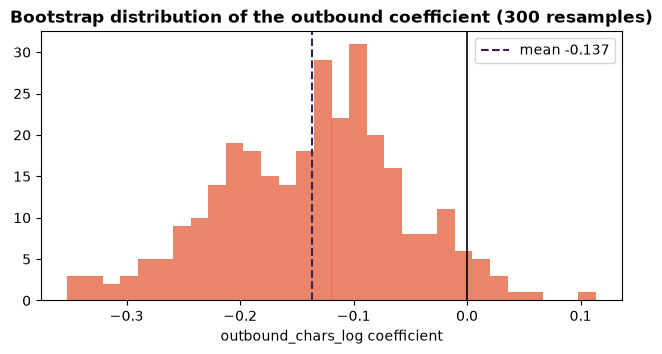

In [11]:
rng = np.random.default_rng(0)
ids = train.submissionId.unique()
groups = {s: train.index[train.submissionId == s].to_numpy() for s in ids}
B = 300
ob_c, in_c = [], []
io, ii = MODEL_FEATURES.index("outbound_chars_log"), MODEL_FEATURES.index("n_inbound_by_t")
for _ in range(B):
    samp = rng.choice(ids, size=len(ids), replace=True)
    bt = train.loc[np.concatenate([groups[s] for s in samp])]
    c = make_model().fit(bt[MODEL_FEATURES], bt.label).named_steps["logisticregression"].coef_[0]
    ob_c.append(c[io]); in_c.append(c[ii])
ob_c, in_c = np.array(ob_c), np.array(in_c)
print(f"outbound coef: mean {ob_c.mean():+.3f}, 90% CI [{np.percentile(ob_c,5):+.3f}, {np.percentile(ob_c,95):+.3f}], P(coef<0) = {(ob_c<0).mean():.0%}")
print(f"inbound  coef: mean {in_c.mean():+.3f}, 90% CI [{np.percentile(in_c,5):+.3f}, {np.percentile(in_c,95):+.3f}], P(coef>0) = {(in_c>0).mean():.0%}")
fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.hist(ob_c, bins=30, color=RED, alpha=0.85)
ax.axvline(0, color="k", lw=1.2)
ax.axvline(ob_c.mean(), color=PURPLE, ls="--", lw=1.5, label=f"mean {ob_c.mean():+.3f}")
ax.set_title("Bootstrap distribution of the outbound coefficient (300 resamples)", fontweight="bold")
ax.set_xlabel("outbound_chars_log coefficient"); ax.legend()
plt.show()

**Read:** if the distribution sits clearly left of 0 (high P(coef<0)), the negative sign is *stable* — the model
reliably assigns outbound a negative weight given the others (a stable suppressor), not random noise. If it straddles
0, the sign is just collinearity instability. (See the printed P(coef<0).)

## 7. Check 3 — partial correlation (add controls one at a time)
Correlation of outbound with the label, removing the linear effect of the controls. Watch the positive marginal
correlation shrink as we control for the quote (and the rest).

In [12]:
from numpy.linalg import lstsq

def _resid(v, X):
    X1 = np.column_stack([np.ones(len(X)), X])
    beta, *_ = lstsq(X1, v, rcond=None)
    return v - X1 @ beta

def pcorr(xv, yv, C):
    return float(np.corrcoef(_resid(xv, C), _resid(yv, C))[0, 1])

xb, lab = panel.outbound_chars_log.values, panel.label.values.astype(float)
print(f"marginal corr(outbound, label)                              = {np.corrcoef(xb, lab)[0,1]:+.3f}")
print(f"partial | has_quote                                         = {pcorr(xb, lab, panel[['has_quote_by_t']].values):+.3f}")
print(f"partial | has_quote + n_inbound                             = {pcorr(xb, lab, panel[['has_quote_by_t','n_inbound_by_t']].values):+.3f}")
print(f"partial | has_quote + n_inbound + agent_bind_rate + t       = {pcorr(xb, lab, panel[['has_quote_by_t','n_inbound_by_t','agent_bind_rate','t']].values):+.3f}")

marginal corr(outbound, label)                              = +0.041
partial | has_quote                                         = -0.022
partial | has_quote + n_inbound                             = -0.050
partial | has_quote + n_inbound + agent_bind_rate + t       = -0.031


**Read:** the marginal correlation is positive, but it collapses (toward / past 0) once `has_quote` (and inbound) are
controlled for — the partial correlation is what the model's coefficient reflects. Confirms: outbound's *unique*
association with binding, after the confounds, is ~nil/slightly negative.

## 8. The split-feature idea — `ob_noquote` + `ob_quote`
Your proposal: instead of one `outbound`, give the model two columns so it can weight "writing while unquoted" and
"writing while quoted" separately. Build them on the log scale and **replace** the single outbound.

In [13]:
p2 = panel.copy()
p2["ob_noquote"] = p2.outbound_chars_log * (1 - p2.has_quote_by_t)
p2["ob_quote"] = p2.outbound_chars_log * p2.has_quote_by_t
tr2, te2, _ = temporal_split(p2); recompute_agent_rate(tr2, te2)
y2 = te2.label.values
cols = ["agent_bind_rate", "has_quote_by_t", "n_inbound_by_t", "t", "ob_noquote", "ob_quote"]
mm = make_model().fit(tr2[cols], tr2.label)
print("coefficients with the split features:")
print(pd.Series(mm.named_steps["logisticregression"].coef_[0], index=cols).round(3).to_string())
cvm = cross_val_score(make_model(), tr2[cols], tr2.label,
                      cv=StratifiedGroupKFold(5, shuffle=True, random_state=0),
                      groups=tr2.submissionId, scoring="roc_auc").mean()
print(f"\ntest AUC {roc_auc_score(y2, mm.predict_proba(te2[cols])[:,1]):.3f}  (base 0.744)"
      f"  |  CV-train {cvm:.3f}  (base 0.608)")

coefficients with the split features:
agent_bind_rate    0.275
has_quote_by_t    -1.039
n_inbound_by_t     0.058
t                 -0.014
ob_noquote        -0.125
ob_quote           1.223

test AUC 0.745  (base 0.744)  |  CV-train 0.608  (base 0.608)


**Read:** splitting does **not** robustly improve AUC (≈ base, no CV gain), and it *worsens* interpretability:
because `ob_noquote`/`ob_quote` are products of features already in the model, they're collinear with `has_quote`,
so the coefficients (including `has_quote` itself) blow up / flip — they stop being readable. The split confirms the
story but isn't worth adopting.

## 9. Conclusion

- **The model is not "learning something wrong" predictively.** AUC is essentially unchanged whether outbound is in,
  out, raw, logged, or binned (§4, §5). The issue is purely the **coefficient's interpretation**, not the prediction.
- **The negative sign is an artifact — and not even a stable one.** It flips with the encoding (raw +0.35, log1p −0.14,
  bins +0.11, §4). Within `log1p` it's stable across bootstraps (96% negative, §6), but that stability is
  *encoding-specific*. So the sign should **not be interpreted** as a real effect in either direction.
- **Why so fragile:** outbound has **almost no unique signal**. Its marginal corr with the label is only **+0.04**
  (§2), it's strongly collinear with `has_quote` (+0.56) and `n_inbound` (+0.53), and **dropping it barely moves AUC**
  (0.744→0.748 test, §5). With ~no unique signal and heavy collinearity, the residual structure is tiny — so the
  transform and the other features decide the sign. The `log1p` partial correlation lands slightly negative (§7);
  the raw scale lands positive.
- **No within-population reversal** — outbound stays *positive* inside both the no-quote and has-quote groups (§3); the
  earlier "heavy-writing-without-a-quote = struggling deal" story is **retracted** (it's a confound from §2, not a
  real conditional effect).
- **The split features don't help** (§8) — no robust AUC gain, and they destabilise the coefficients (collinearity).
- **It does *not* clearly earn its place — but the selection is noise-dominated** (§5c). Under exhaustive best-subset
  with multi-seed CV, every subset is within ~0.005 (CV p@20) of every other, and a single-seed greedy run that once
  made outbound look like "the best single feature" doesn't survive averaging. The held-out test — the one
  out-of-sample arbiter — mildly favors keeping the full set (≈0.744 vs 0.733 AUC; a ~3-submission gap, inside the
  ±0.04 standard error of precision@20).

**Decision: keep `outbound_chars_log`** — not because it "earns its place," but because *which* of these correlated
predictors to keep is below the noise floor (with ~130 positives), the held-out arbiter mildly favors the full set,
keeping it costs nothing, and the challenge asks for 3–4 features. **Do not interpret its coefficient's sign:** that
sign is a meaningless collinearity artifact (flips with the encoding, §4), separate from whether the feature helps.
For "what is its effect direction", the honest answer is *undetermined* (collinear with quote + inbound). The
report's §2.2 / §2.3 and `decisions.md` reflect this.